# Contact High School

## Node-labeled task

- Compare CIHI, HFRC, and HORC on distinguishing within-community vs between-community hyperedges and on pairwise metric correlation.
- Compare hypergraph community-detection algorithms before and after curvature-based surgery.


In [9]:
import sys
from pathlib import Path
candidates = [Path.cwd(), Path.cwd() / "code", *Path.cwd().parents]
CODE_ROOT = next(p for p in candidates if (p / "src" / "__init__.py").is_file())
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from plotnine import *
Zissou1 = ["#3B9AB2", "#78B7C5", "#EBCC2A", "#E1AF00", "#F21A00"]
Zissou1Continuous = ["#3A9AB2", "#6FB2C1", "#91BAB6", "#A5C2A3", "#BDC881", "#DCCB4E", "#E3B710", "#E79805", "#EC7A05", "#EF5703", "#F11B00"]
# from scipy.optimize import linear_sum_assignment
# from sklearn.metrics import adjusted_rand_score, f1_score, normalized_mutual_info_score
# from sklearn.mixture import GaussianMixture

for p in [Path.cwd(), *Path.cwd().parents]:
    if (p / "src" / "__init__.py").exists():
        sys.path.append(str(p))
        break

from src import load_data
# from src.community_detect import (
#     hypergraph_spectral_embedding,
#     hypergraph_clique_modularity_maximization,
#     hypergraph_modularity_maximization,
#     hypergraph_spectral_clustering,
# )
from src.hellinger_dist import hellinger_distance

sns.set_theme(style="whitegrid", context="talk")

contact_node_color = {
    "2BIO1": "#752104", "2BIO2": "#BB5A3F", "2BIO3": "#EA7E73",
    "MP": "#1B1464", "MP*1": "#2E5AB4", "MP*2": "#00A0C8",
    "PC": "#006837", "PC*": "#39B54A", "PSI*": "#F7931E",
}
contact_label_order = list(contact_node_color)


In [2]:
ds = load_data(dname="contact", data_folder="../../data")
cihi = ds.get_cihi()
hfrc = ds.get_hfrc()
all_horc = ds.get_horc(all_configurations=True)
horc = pd.DataFrame(all_horc, dtype=float)

## Shared Helpers

In [3]:
def node_labels_for_nodes(data, nodes=None):
    """Return node labels aligned to ``nodes``. Contact node ids are 1-based."""
    nodes = data.node_order() if nodes is None else list(nodes)
    if min(nodes) >= 1 and max(nodes) <= len(data.node_labels):
        return np.array([data.node_labels[v - 1] for v in nodes])
    return np.array([data.node_labels[v] for v in nodes])


def hyperedge_key(edge):
    """Canonical hyperedge key used to align external per-edge scores."""
    return tuple(sorted({int(v) for v in edge}))


def horc_hyperedge_key(edge_string):
    return hyperedge_key(edge_string.split(","))


def align_horc_to_dataset(horc_frame, data):
    """Return HORC rows in exactly ``data.hyperedges`` order."""
    frame = horc_frame.copy()
    frame["edge_key"] = [horc_hyperedge_key(s) for s in frame["hyperedge"]]
    if frame["edge_key"].duplicated().any():
        raise ValueError("HORC table has duplicate hyperedges; cannot align safely.")

    expected = [hyperedge_key(edge) for edge in data.hyperedges]
    missing = set(expected) - set(frame["edge_key"])
    extra = set(frame["edge_key"]) - set(expected)
    if missing or extra:
        raise ValueError(
            f"HORC/data hyperedges differ: {len(missing)} missing, {len(extra)} extra"
        )

    return frame.set_index("edge_key").loc[expected].reset_index(drop=True)


def hyperedge_label(edge, data):
    labels = node_labels_for_nodes(data, sorted(set(edge)))
    return "intra" if len(set(labels)) == 1 else "inter"


def hyperedge_labels(data):
    return [hyperedge_label(edge, data) for edge in data.hyperedges]


def horc_hyperedge_label(edge_string, data):
    edge = [int(v) for v in edge_string.split(",")]
    return hyperedge_label(edge, data)


def as_float_array(values):
    return np.array([np.nan if x is None else x for x in values], dtype=float)


def hellinger_by_group(frame, value_col, label_col="edge_label", a="intra", b="inter"):
    x = frame.loc[frame[label_col] == a, value_col].dropna().to_numpy()
    y = frame.loc[frame[label_col] == b, value_col].dropna().to_numpy()
    return hellinger_distance(x, y)


def best_horc_metric(horc_frame):
    metrics = [c for c in horc_frame.columns if c.startswith("horc_")]
    return max(metrics, key=lambda col: hellinger_by_group(horc_frame, col))


def partition_to_array(partition, nodes):
    return np.array([partition[v] for v in nodes])


def macro_f1_cluster(y_true, y_pred):
    """Map cluster ids to labels with Hungarian matching, then compute macro-F1."""
    true_vals, pred_vals = np.unique(y_true), np.unique(y_pred)
    true_index = {v: i for i, v in enumerate(true_vals)}
    pred_index = {v: i for i, v in enumerate(pred_vals)}
    counts = np.zeros((len(true_vals), len(pred_vals)), dtype=int)

    for true_label, pred_label in zip(y_true, y_pred):
        counts[true_index[true_label], pred_index[pred_label]] += 1

    rows, cols = linear_sum_assignment(-counts)
    pred_to_true = {pred_vals[c]: true_vals[r] for r, c in zip(rows, cols)}
    for pred_label in pred_vals:
        if pred_label not in pred_to_true:
            pred_to_true[pred_label] = true_vals[counts[:, pred_index[pred_label]].argmax()]

    mapped = np.array([pred_to_true[p] for p in y_pred])
    return f1_score(y_true, mapped, average="macro")


def evaluate_partition(name, partition, data=ds, nodes=None, **extra):
    nodes = data.node_order() if nodes is None else list(nodes)
    y_true = node_labels_for_nodes(data, nodes)
    y_pred = partition_to_array(partition, nodes)
    row = {
        "method": name,
        "n_clusters": len(np.unique(y_pred)),
        "NMI": normalized_mutual_info_score(y_true, y_pred),
        "ARI": adjusted_rand_score(y_true, y_pred),
        "macro_F1": macro_f1_cluster(y_true, y_pred),
    }
    row.update(extra)
    return row


def spectral_hyperedge_dispersion(edge, embedding, node_to_idx):
    idx = [node_to_idx[v] for v in set(edge)]
    if len(idx) <= 1:
        return np.nan
    X = embedding[idx]
    center = X.mean(axis=0)
    return float(np.mean(np.sum((X - center) ** 2, axis=1)))


def hyperedge_cut_score(edge, partition):
    labels = [partition[v] for v in set(edge)]
    d = len(labels)
    if d <= 1:
        return np.nan
    _, counts = np.unique(labels, return_counts=True)
    same_pairs = np.sum(counts * (counts - 1) / 2)
    total_pairs = d * (d - 1) / 2
    return float(1 - same_pairs / total_pairs)


def fit_gmm_removal_mask(values, n_components=2, posterior_threshold=0.5, seed=0, remove_low=True):
    values = as_float_array(values)
    finite = np.isfinite(values)
    if finite.sum() == 0:
        raise ValueError("No finite values available for GMM fitting.")

    X = values[finite].reshape(-1, 1)
    gmm = GaussianMixture(
        n_components=n_components,
        covariance_type="full",
        random_state=seed,
        n_init=20,
    ).fit(X)

    means = gmm.means_.ravel()
    removal_component = np.argmin(means) if remove_low else np.argmax(means)

    posterior = np.full(len(values), np.nan)
    posterior[finite] = gmm.predict_proba(X)[:, removal_component]

    remove_edge = np.zeros(len(values), dtype=bool)
    remove_edge[finite] = posterior[finite] >= posterior_threshold

    cutoff = np.nan
    if remove_edge.any():
        cutoff = np.nanmax(values[remove_edge]) if remove_low else np.nanmin(values[remove_edge])

    return {
        "remove_edge": remove_edge,
        "cutoff": cutoff,
        "posterior": posterior,
        "gmm": gmm,
        "means": means,
        "removed_fraction": remove_edge.mean(),
    }


def components_after_removal(data, remove_edge):
    nodes = data.node_order()
    parent = {v: v for v in nodes}

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[rb] = ra

    for edge, remove in zip(data.hyperedges, remove_edge):
        if remove or len(edge) < 2:
            continue
        first = edge[0]
        for v in edge[1:]:
            union(first, v)

    root_to_label = {}
    partition = {}
    for v in nodes:
        root = find(v)
        if root not in root_to_label:
            root_to_label[root] = len(root_to_label)
        partition[v] = root_to_label[root]
    return partition


def make_surgery_hypergraph(data, remove_edge, keep_isolated_nodes=True):
    kept_edges = [
        list(dict.fromkeys(edge))
        for edge, remove in zip(data.hyperedges, remove_edge)
        if not remove
    ]

    if keep_isolated_nodes:
        original_nodes = set(data.node_order())
        present_nodes = {v for edge in kept_edges for v in edge}
        kept_edges += [[v] for v in sorted(original_nodes - present_nodes)]

    return HypergraphDataset(
        kept_edges,
        node_labels=data.node_labels,
        edge_labels=None,
        hypergraph_idx=None,
        hypergraph_labels=None,
    )


def run_community_detection_suite(data, num_clusters, seed=0):
    """Run the same community-detection suite on one hypergraph."""
    partitions = {
        "Hypergraph spectral, fixed k": hypergraph_spectral_clustering(
            data,
            num_clusters=num_clusters,
            seed=seed,
            solver="sparse",
            eig_tol=1e-3,
        ),
        "IRMM modularity, target k": hypergraph_modularity_maximization(
            data,
            num_clusters=num_clusters,
            max_iter=12,
            seed=seed,
        ),
        "Clique Louvain baseline": hypergraph_clique_modularity_maximization(
            data,
            seed=seed,
        ),
    }
    results = pd.DataFrame([
        evaluate_partition(method, partition, data=data)
        for method, partition in partitions.items()
    ])
    return results, partitions


def component_size_summary(partition, top=10):
    sizes = pd.Series(list(partition.values())).value_counts().sort_values(ascending=False)
    return {
        "n_components": len(sizes),
        "largest_components": tuple(sizes.head(top).astype(int)),
    }


def surgery_removal_diagnostics(name, fit, partition, edge_labels):
    remove_edge = fit["remove_edge"]
    edge_labels = np.asarray(edge_labels)
    component_stats = component_size_summary(partition)
    row = {
        "surgery": name,
        "removed_edges": int(remove_edge.sum()),
        "removed_fraction": float(remove_edge.mean()),
        "removed_inter": int(((edge_labels == "inter") & remove_edge).sum()),
        "removed_intra": int(((edge_labels == "intra") & remove_edge).sum()),
        "pct_inter_removed": float(((edge_labels == "inter") & remove_edge).sum() / (edge_labels == "inter").sum()),
        "pct_intra_removed": float(((edge_labels == "intra") & remove_edge).sum() / (edge_labels == "intra").sum()),
        "cutoff": fit["cutoff"],
        "gmm_means": tuple(np.round(fit["means"], 4)),
    }
    row.update(component_stats)
    return row


def run_gmm_surgery(name, values, data=ds, n_components=2, posterior_threshold=0.5, seed=0, remove_low=True):
    fit = fit_gmm_removal_mask(
        values,
        n_components=n_components,
        posterior_threshold=posterior_threshold,
        seed=seed,
        remove_low=remove_low,
    )
    partition = components_after_removal(data, fit["remove_edge"])
    row = evaluate_partition(
        name,
        partition,
        data=data,
        cutoff=fit["cutoff"],
        removed_fraction=fit["removed_fraction"],
        gmm_means=tuple(np.round(fit["means"], 4)),
    )
    return row, partition, fit


## Compare with Curvature Metrics

In [4]:
edge_label = hyperedge_labels(ds)

edge_df = pd.DataFrame({
    "edge_label": edge_label,
    "cihi": as_float_array(ds.get_cihi()),
    "hfrc": as_float_array(ds.get_hfrc()),
})
horc["edge_label"] = edge_label
horc_metrics = [c for c in horc.columns if c == "horc" or c.startswith("horc_")]
best_horc = max(horc_metrics,key=lambda col: hellinger_by_group(horc, col),)

print(edge_df["edge_label"].value_counts())
print("Best HORC metric:", best_horc)


edge_label
intra    5720
inter    2098
Name: count, dtype: int64
Best HORC metric: horc_uw_clique_max_a0p5


In [5]:
curvature_distance = pd.DataFrame([
    {"metric": "CIHI", "column": "cihi", "hellinger": hellinger_by_group(edge_df, "cihi")},
    {"metric": "HFRC", "column": "hfrc", "hellinger": hellinger_by_group(edge_df, "hfrc")},
    {"metric": "HORC", "column": best_horc, "hellinger": hellinger_by_group(horc, best_horc)},
])

curvature_distance


,metric,column,hellinger
0,CIHI,cihi,0.884306
1,HFRC,hfrc,0.166670
2,HORC,horc_uw_clique_max_a0p5,0.876270


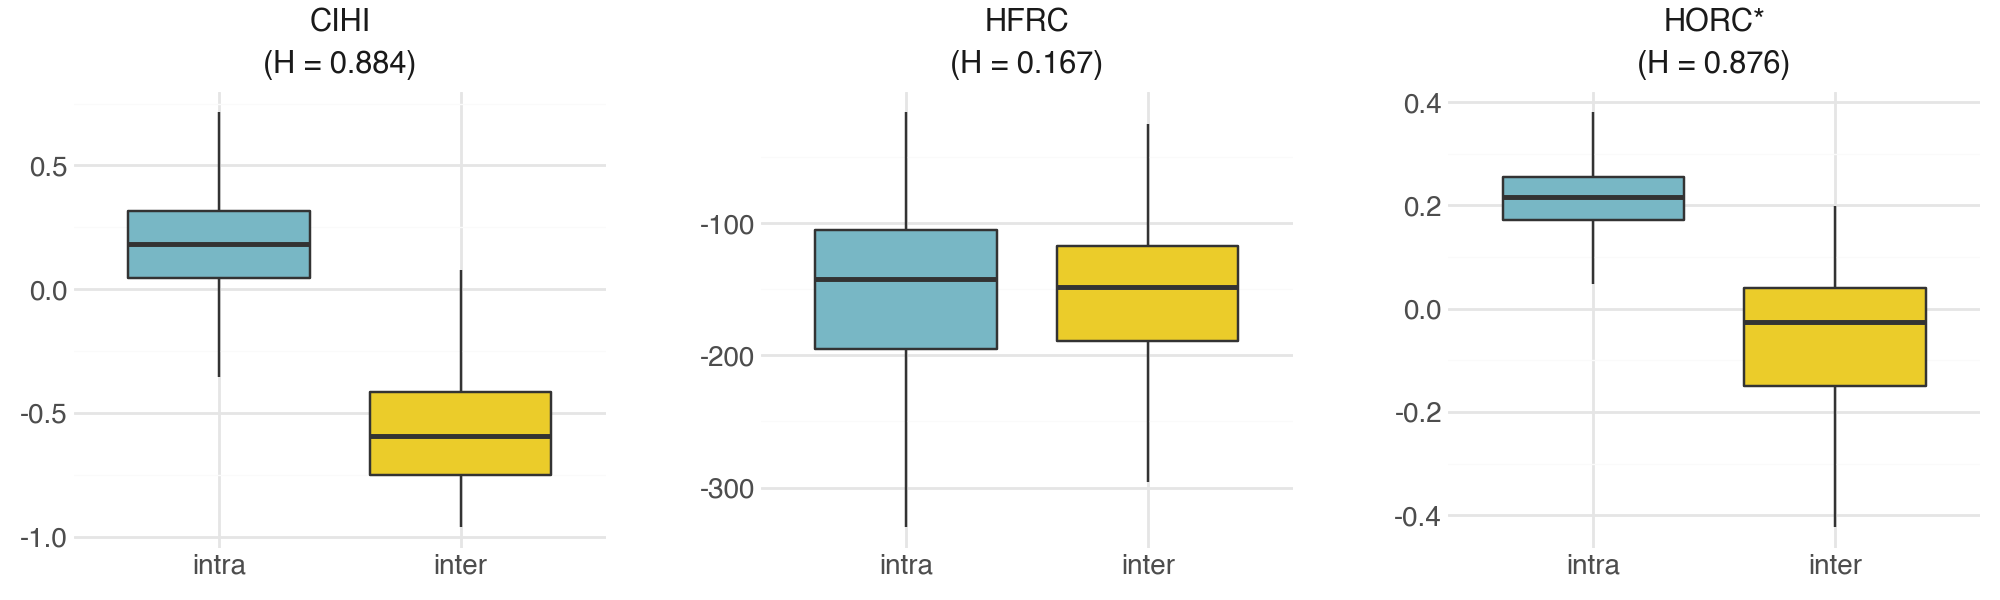

In [6]:
plot_df = pd.concat([
    edge_df[["edge_label", "cihi", "hfrc"]],
    horc[[best_horc]].rename(columns={best_horc: "horc"}),
], axis=1)

h_values = {
    "cihi": hellinger_by_group(edge_df, "cihi"),
    "hfrc": hellinger_by_group(edge_df, "hfrc"),
    "horc": hellinger_by_group(horc, best_horc),
}

metric_titles = {
    "cihi": f"CIHI\n(H = {h_values['cihi']:.3f})",
    "hfrc": f"HFRC\n(H = {h_values['hfrc']:.3f})",
    "horc": f"HORC*\n(H = {h_values['horc']:.3f})",
}
palette = {"intra": Zissou1[1],"inter": Zissou1[2]}

long_df = plot_df.melt(id_vars="edge_label", var_name="metric", value_name="score")
long_df["edge_label"] = pd.Categorical(long_df["edge_label"], ["intra", "inter"], ordered=True)
long_df["metric_title"] = pd.Categorical(long_df["metric"].map(metric_titles), list(metric_titles.values()), ordered=True)

p = (
    ggplot(long_df, aes("edge_label", "score", fill="edge_label"))
    + geom_boxplot(outlier_shape="")
    + facet_wrap("metric_title", scales="free_y", nrow=1)
    + scale_fill_manual(values=palette)
    + labs(x="", y="")
    + theme_minimal()
    + theme(
        figure_size=(10, 3),
        legend_position="none",
        panel_spacing_x=0.05,
        strip_text=element_text(size=11),
        axis_title_y=element_text(size=11),
        axis_text=element_text(size=10),
    )
)

p

### Correlation Analysis

Pearson captures linear agreement between metric values; Spearman captures rank agreement. Correlations are computed directly between curvature metrics over all hyperedges, without using node labels or edge labels.


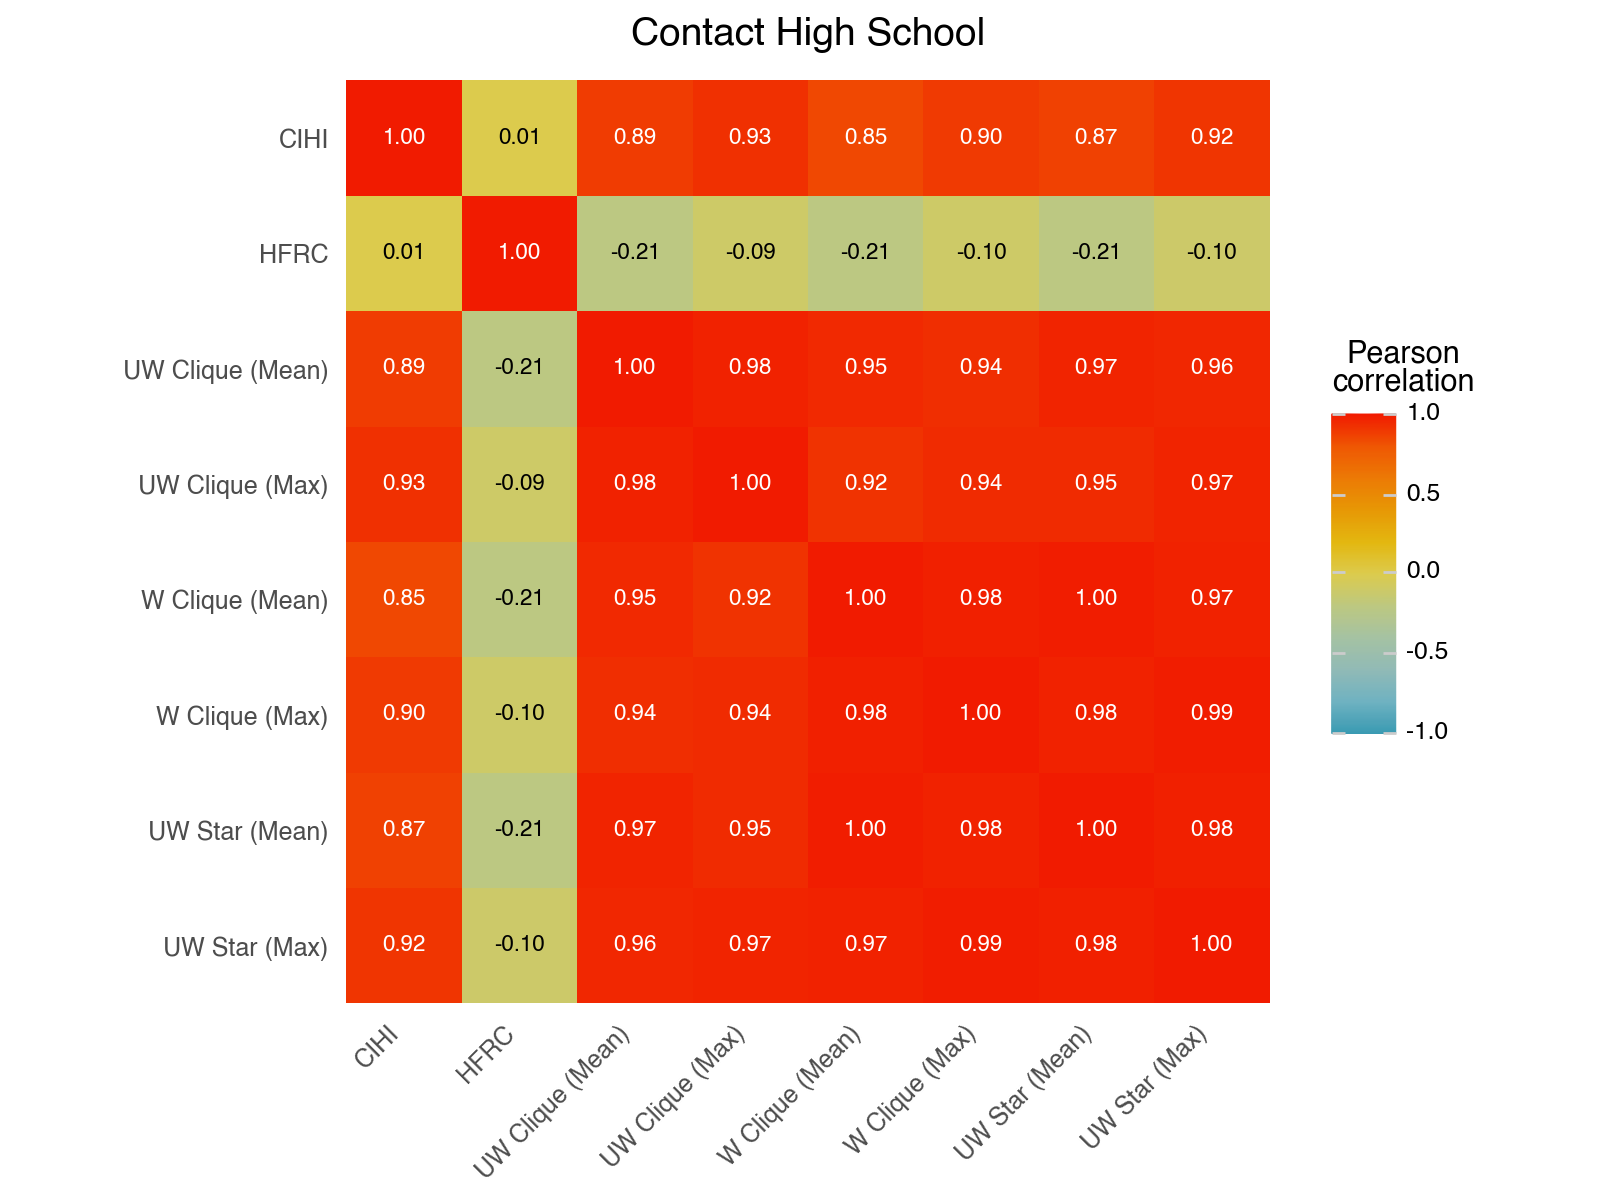

In [12]:
metrics = [c for c in horc if c == "horc" or c.endswith("_a0p0")]
labels = {
    "cihi": "CIHI", "hfrc": "HFRC", "horc": "UW Clique (Mean)",
    "horc_uw_clique_max_a0p0": "UW Clique (Max)",
    "horc_w_clique_mean_a0p0": "W Clique (Mean)",
    "horc_w_clique_max_a0p0": "W Clique (Max)",
    "horc_uw_star_mean_a0p0": "UW Star (Mean)",
    "horc_uw_star_max_a0p0": "UW Star (Max)",
}

corr_data = pd.concat([edge_df[["cihi", "hfrc"]], horc[metrics]], axis=1)
corr = corr_data.corr().rename(index=labels, columns=labels)

corr_long = pd.DataFrame(
    [(y, x, corr.loc[y, x]) for y in corr.index for x in corr.columns],
    columns=["metric_y", "metric_x", "correlation"],
)
corr_long["label"] = corr_long["correlation"].map(lambda x: f"{x:.2f}")
corr_long["text_color"] = np.where(abs(corr_long["correlation"]) > 0.75, "white", "black")

order = list(corr.columns)
corr_long["metric_x"] = pd.Categorical(corr_long["metric_x"], order, ordered=True)
corr_long["metric_y"] = pd.Categorical(corr_long["metric_y"], order[::-1], ordered=True)

p_corr = (
    ggplot(corr_long, aes("metric_x", "metric_y", fill="correlation"))
    + geom_tile()
    + geom_text(aes(label="label", color="text_color"), size=8)
    + scale_fill_gradientn(colors=Zissou1Continuous, limits=(-1, 1), name="Pearson\ncorrelation")
    + scale_color_identity()
    + coord_equal()
    + labs(title=r"Contact High School", x="", y="")
    + theme_minimal()
    + theme(
        figure_size=(8, 6),
        plot_title=element_text(size=14, ha="center"),
        axis_text_x=element_text(rotation=45, ha="right", size=9),
        axis_text_y=element_text(size=9),
        panel_grid=element_blank(),
    )
)

p_corr

In [13]:
p_corr.save(
    CODE_ROOT / "contact" / "contact_corr.pdf",
    width=6,
    height=5,
    units="in",
    verbose=False,
)

## Compare with Community Detection Algorithms

### Case A: Per-Hyperedge Discrimination

Convert node-level community methods into one scalar score per hyperedge, then compare `intra` vs `inter` distributions.


- **Spectral Dispersion**: Hypergraph spectral clustering gives each node a vector in a low-dimensional spectral embedding space.
    For one hyperedge e, we take all member nodes of e, look up their spectral vectors, and measure how spread out they are
    ```pseduo
    center = mean embedding of nodes in e
    spectral_dispersion(e) = average squared distance to center
    ```
    - low spectral_dispersion:
        nodes in the hyperedge are close in spectral space
        likely intra-community
    - high spectral_dispersion:
        nodes in the hyperedge are far apart in spectral space
        likely inter-community / bridge hyperedge
- **Modularity Cut**: Modularity maximization gives each node a discrete community label.
    For one hyperedge e, we look at all pairs of nodes inside that hyperedge and ask what fraction of pairs are split across different detected communities.
    ```pseduo
    modularity_cut(e) = 1 - same-community-pairs / all-node-pairs
    ```
    - modularity_cut = 0:
        all nodes in the hyperedge are in the same detected community
        strongly intra-community
    - modularity_cut close to 1:
        most node pairs in the hyperedge are in different detected communities
        strongly inter-community

In [7]:
nodes = ds.node_order()
node_to_idx = {v: i for i, v in enumerate(nodes)}
y_true = node_labels_for_nodes(ds, nodes)
k_true = len(np.unique(y_true))

spectral_embedding = hypergraph_spectral_embedding(
    ds,
    num_clusters=k_true,
    edge_weights=None,
    solver="sparse",
    eig_tol=1e-3,
    eig_max_iter=None,
)

modularity_partition = hypergraph_modularity_maximization(
    ds,
    num_clusters=k_true,
    max_iter=12,
    seed=0,
)

edge_score_df = edge_df.copy()
edge_score_df["best_horc"] = horc[best_horc].to_numpy()
edge_score_df["spectral_dispersion"] = [
    spectral_hyperedge_dispersion(edge, spectral_embedding, node_to_idx)
    for edge in ds.hyperedges
]
edge_score_df["modularity_cut"] = [
    hyperedge_cut_score(edge, modularity_partition)
    for edge in ds.hyperedges
]

per_hyperedge_distance = pd.DataFrame([
    {"method": "CIHI", "score": "cihi", "hellinger": hellinger_by_group(edge_score_df, "cihi")},
    {"method": "HFRC", "score": "hfrc", "hellinger": hellinger_by_group(edge_score_df, "hfrc")},
    {"method": "HORC", "score": best_horc, "hellinger": hellinger_by_group(edge_score_df, "best_horc")},
    {"method": "Spectral", "score": "spectral_dispersion", "hellinger": hellinger_by_group(edge_score_df, "spectral_dispersion")},
    {"method": "IRMM modularity", "score": "modularity_cut", "hellinger": hellinger_by_group(edge_score_df, "modularity_cut")},
]).sort_values("hellinger", ascending=False)

per_hyperedge_distance


,method,score,hellinger
3,Spectral,spectral_dispersion,0.948927
0,CIHI,cihi,0.884306
2,HORC,horc_uw_clique_max_a0p5,0.876873
4,IRMM modularity,modularity_cut,0.762609
1,HFRC,hfrc,0.166670


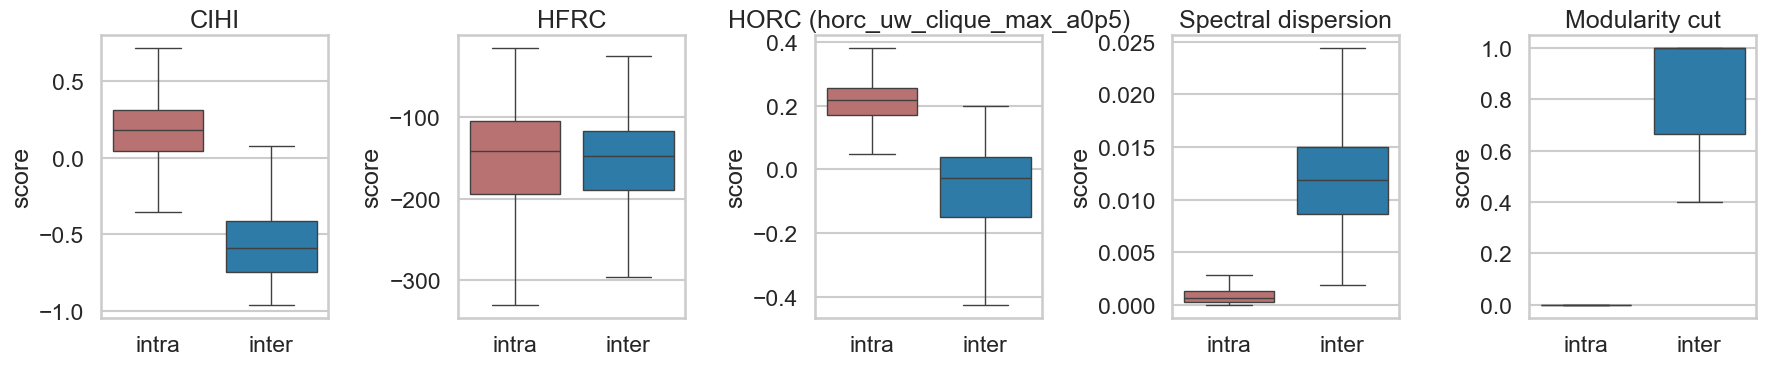

In [8]:
score_titles = {
    "cihi": "CIHI",
    "hfrc": "HFRC",
    "best_horc": f"HORC ({best_horc})",
    "spectral_dispersion": "Spectral dispersion",
    "modularity_cut": "Modularity cut",
}
palette = {"intra": "#c46666", "inter": "#1a80bb"}
scores = ["cihi", "hfrc", "best_horc", "spectral_dispersion", "modularity_cut"]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=False)

for ax, score in zip(axes, scores):
    sns.boxplot(
        data=edge_score_df,
        x="edge_label",
        y=score,
        hue="edge_label",
        order=["intra", "inter"],
        hue_order=["intra", "inter"],
        palette=palette,
        showfliers=False,
        legend=False,
        ax=ax,
    )
    ax.set_title(score_titles[score])
    ax.set_xlabel("")
    ax.set_ylabel("score")

plt.tight_layout()
plt.show()


### Case B: Community-Detection Benchmark

Compare node partitions against true class labels with NMI, ARI, and macro-F1.


In [9]:
community_results, community_partitions = run_community_detection_suite(ds, k_true, seed=0)
community_results


,method,n_clusters,NMI,ARI,macro_F1
0,"Hypergraph spectral, fixed k",9,0.993567,0.992995,0.996983
1,"IRMM modularity, target k",8,0.954551,0.893563,0.854299
2,Clique Louvain baseline,7,0.909727,0.795242,0.705475


### Case C: Curvature-Based Surgery

Fit a Gaussian mixture to each hyperedge score, remove hyperedges assigned to the low-score component, then use connected components as communities.


In [10]:
surgery_specs = [
    ("CIHI GMM surgery", edge_score_df["cihi"].to_numpy(), True),
    ("HFRC GMM surgery", edge_score_df["hfrc"].to_numpy(), True),
    ("HORC GMM surgery", edge_score_df["best_horc"].to_numpy(), True),
]

surgery_rows = []
surgery_diagnostic_rows = []
surgery_partitions = {}
surgery_fits = {}

for name, values, remove_low in surgery_specs:
    row, partition, fit = run_gmm_surgery(
        name,
        values,
        data=ds,
        n_components=2,
        posterior_threshold=0.5,
        seed=0,
        remove_low=remove_low,
    )
    surgery_rows.append(row)
    surgery_diagnostic_rows.append(surgery_removal_diagnostics(name, fit, partition, edge_label))
    surgery_partitions[name] = partition
    surgery_fits[name] = fit

surgery_results = pd.DataFrame(surgery_rows)
surgery_diagnostics = pd.DataFrame(surgery_diagnostic_rows)
surgery_results


,method,n_clusters,NMI,ARI,macro_F1,cutoff,removed_fraction,gmm_means
0,CIHI GMM surgery,3,0.452710,0.182765,0.104274,-0.234874,0.265797,"(0.1789, -0.5726)"
1,HFRC GMM surgery,1,0.000000,0.000000,0.026355,-187.000000,0.272832,"(-123.5397, -221.4637)"
2,HORC GMM surgery,11,0.736165,0.478550,0.347390,0.084815,0.266564,"(0.2129, -0.0392)"


#### Surgery evaluation with grouped node labels

Only for Case C, merge node labels into three coarse communities: BIO, MP, and PC/PSI. The surgery partitions are unchanged; only the ground-truth labels used by NMI / ARI / macro-F1 are grouped.


In [11]:
grouped_label_map = {
    "2BIO1": "BIO", "2BIO2": "BIO", "2BIO3": "BIO",
    "MP": "MP", "MP*1": "MP", "MP*2": "MP",
    "PC": "PC/PSI", "PC*": "PC/PSI", "PSI*": "PC/PSI",
}


def grouped_node_labels(data, nodes=None):
    nodes = data.node_order() if nodes is None else list(nodes)
    fine_labels = node_labels_for_nodes(data, nodes)
    return np.array([grouped_label_map[label] for label in fine_labels])


def evaluate_partition_grouped_labels(name, partition, data=ds, nodes=None, **extra):
    nodes = data.node_order() if nodes is None else list(nodes)
    y_true_grouped = grouped_node_labels(data, nodes)
    y_pred = partition_to_array(partition, nodes)
    row = {
        "method": name,
        "n_clusters": len(np.unique(y_pred)),
        "NMI": normalized_mutual_info_score(y_true_grouped, y_pred),
        "ARI": adjusted_rand_score(y_true_grouped, y_pred),
        "macro_F1": macro_f1_cluster(y_true_grouped, y_pred),
    }
    row.update(extra)
    return row


surgery_grouped_rows = []
for name, partition in surgery_partitions.items():
    fit = surgery_fits[name]
    surgery_grouped_rows.append(evaluate_partition_grouped_labels(
        name,
        partition,
        data=ds,
        removed_fraction=fit["removed_fraction"],
        cutoff=fit["cutoff"],
        gmm_means=tuple(np.round(fit["means"], 4)),
    ))

surgery_results_grouped_labels = pd.DataFrame(surgery_grouped_rows)
surgery_results_grouped_labels


,method,n_clusters,NMI,ARI,macro_F1,removed_fraction,cutoff,gmm_means
0,CIHI GMM surgery,3,0.730611,0.575336,0.574168,0.265797,-0.234874,"(0.1789, -0.5726)"
1,HFRC GMM surgery,1,0.000000,0.000000,0.175676,0.272832,-187.000000,"(-123.5397, -221.4637)"
2,HORC GMM surgery,11,0.863962,0.841781,1.000000,0.266564,0.084815,"(0.2129, -0.0392)"


#### Surgery removal diagnostics

Use this to verify whether a surgery removes mostly inter-community edges and whether it fragments the hypergraph into many connected components.


In [12]:
surgery_diagnostics


,surgery,removed_edges,removed_fraction,removed_inter,removed_intra,pct_inter_removed,pct_intra_removed,cutoff,gmm_means,n_components,largest_components
0,CIHI GMM surgery,2078,0.265797,1911,167,0.910867,0.029196,-0.234874,"(0.1789, -0.5726)",3,"(216, 110, 1)"
1,HFRC GMM surgery,2133,0.272832,545,1588,0.259771,0.277622,-187.000000,"(-123.5397, -221.4637)",1,"(327,)"
2,HORC GMM surgery,2084,0.266564,1888,196,0.899905,0.034266,0.084815,"(0.2129, -0.0392)",11,"(108, 95, 83, 33, 2, 1, 1, 1, 1, 1)"


### Case C.1: UMAP After Surgery

UMAP is fit on node adjacency-profile features from the original hypergraph plus each post-surgery hypergraph. Points are nodes; facets are original / CIHI surgery / HFRC surgery / HORC surgery.


In [13]:
try:
    import umap.umap_ as umap
except ModuleNotFoundError:
    umap = None
    print("UMAP is not installed. Run this in a notebook cell first: %pip install umap-learn")


def adjacency_umap_features(data):
    """Node features for UMAP: normalized weighted clique-adjacency rows."""
    A = data.adjacency_matrix(weighted=True, normalize_by_edge_size=True)
    norms = np.linalg.norm(A, axis=1, keepdims=True)
    return A / np.where(norms == 0, 1.0, norms)


if umap is not None:
    umap_datasets = {"Original": ds}
    for surgery_name, fit in surgery_fits.items():
        umap_datasets[surgery_name] = make_surgery_hypergraph(
            ds,
            fit["remove_edge"],
            keep_isolated_nodes=True,
        )

    X_parts = [adjacency_umap_features(data) for data in umap_datasets.values()]
    X = np.vstack(X_parts)

    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.05,
        metric="cosine",
        random_state=0,
    )
    coords = reducer.fit_transform(X)

    rows = []
    start = 0
    for condition, data in umap_datasets.items():
        nodes_condition = data.node_order()
        labels_condition = node_labels_for_nodes(data, nodes_condition)
        partition = surgery_partitions.get(condition)
        condition_coords = coords[start:start + len(nodes_condition)]
        start += len(nodes_condition)

        for node, label, xy in zip(nodes_condition, labels_condition, condition_coords):
            rows.append({
                "condition": condition,
                "node": node,
                "true_label": label,
                "component": partition[node] if partition is not None else np.nan,
                "umap1": xy[0],
                "umap2": xy[1],
            })

    umap_df = pd.DataFrame(rows)
else:
    umap_df = pd.DataFrame()

umap_df.head()


/Users/shiyi/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Research/CIHI/Lower Ricci Curvature for Hypergraph/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/shiyi/Library/Mobile Documents/com~apple~CloudDocs/Desktop/Research/CIHI/Lower Ricci Curvature for Hypergraph/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,condition,node,true_label,component,umap1,umap2
0,Original,1,MP,NaN,7.382259,5.535846
1,Original,2,MP,NaN,7.393963,5.512237
2,Original,3,2BIO3,NaN,7.639234,5.360565
3,Original,4,2BIO3,NaN,7.557916,5.425548
4,Original,5,PC*,NaN,7.228329,5.844473


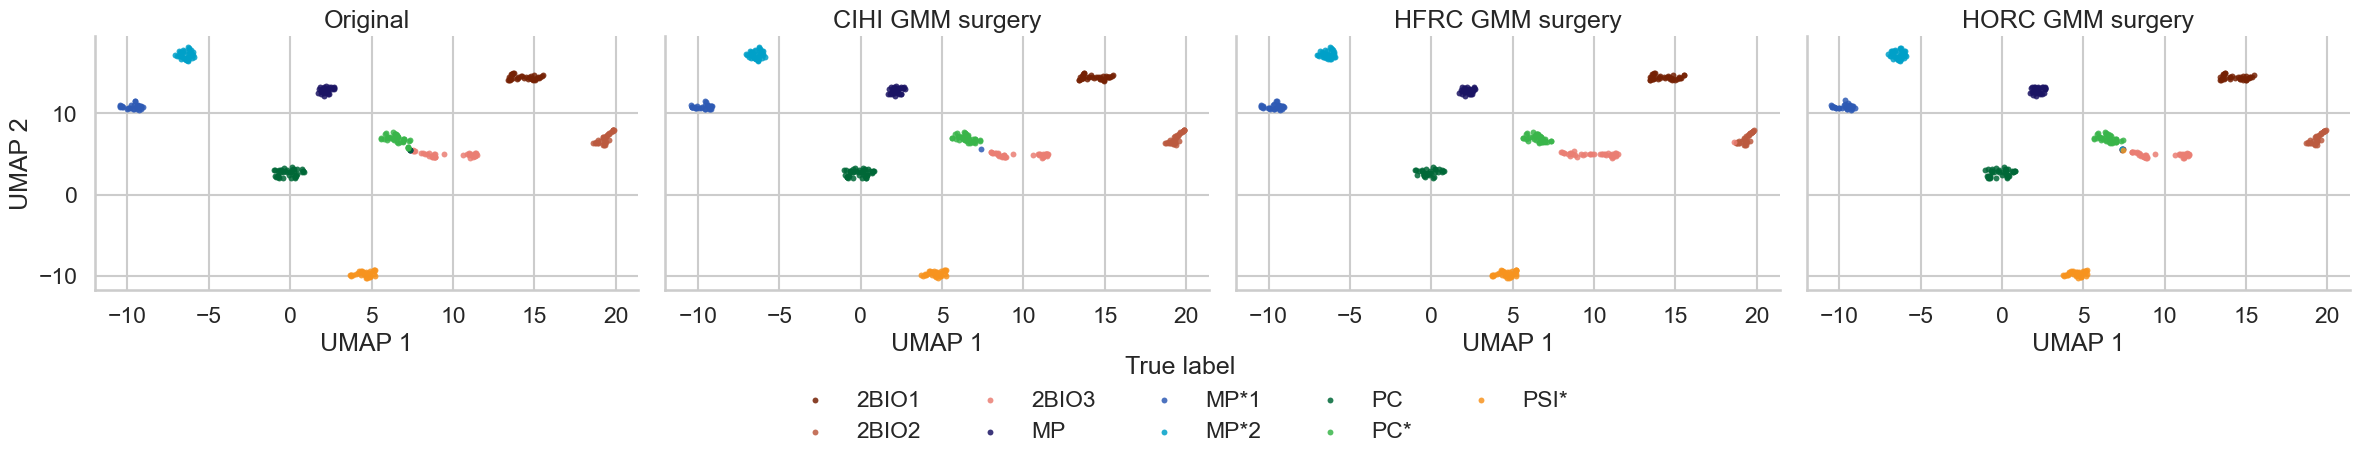

In [14]:
if not umap_df.empty:
    g = sns.FacetGrid(
        umap_df,
        col="condition",
        col_wrap=4,
        hue="true_label",
        palette=contact_node_color,
        hue_order=contact_label_order,
        height=4,
        sharex=True,
        sharey=True,
    )
    g.map_dataframe(
        sns.scatterplot,
        x="umap1",
        y="umap2",
        s=18,
        alpha=0.85,
        linewidth=0,
    )
    g.add_legend(
        title="True label",
        loc="lower center",
        bbox_to_anchor=(0.5, -0.2),
        ncol=5,
        frameon=False,
    )
    g.set_axis_labels("UMAP 1", "UMAP 2")
    g.set_titles("{col_name}")
    plt.tight_layout()
    plt.show()


### Case D: Community Detection After CIHI, HFRC, and HORC Surgery

The purpose of community detection after curvature surgery is to test whether removing low-curvature hyperedges, interpreted as likely bridges between otherwise coherent groups, reveals a topology that is more consistent with the known node communities.


In [15]:
surgery_datasets = {}
surgery_summary_rows = []

for surgery_name, fit in surgery_fits.items():
    ds_after = make_surgery_hypergraph(ds, fit["remove_edge"], keep_isolated_nodes=True)
    surgery_datasets[surgery_name] = ds_after
    surgery_summary_rows.append({
        "surgery": surgery_name,
        "before_edges": ds.num_hyperedges,
        "after_edges": ds_after.num_hyperedges,
        "removed_edges": int(fit["remove_edge"].sum()),
        "removed_fraction": fit["removed_fraction"],
        "cutoff": fit["cutoff"],
        "gmm_means": tuple(np.round(fit["means"], 4)),
    })

surgery_dataset_summary = pd.DataFrame(surgery_summary_rows)
surgery_dataset_summary


,surgery,before_edges,after_edges,removed_edges,removed_fraction,cutoff,gmm_means
0,CIHI GMM surgery,7818,5741,2078,0.265797,-0.234874,"(0.1789, -0.5726)"
1,HFRC GMM surgery,7818,5685,2133,0.272832,-187.000000,"(-123.5397, -221.4637)"
2,HORC GMM surgery,7818,5740,2084,0.266564,0.084815,"(0.2129, -0.0392)"


In [16]:
after_surgery_rows = []
after_surgery_partitions = {}
metric_cols = ["n_clusters", "NMI", "ARI", "macro_F1"]
before_by_method = community_results.set_index("method")

for surgery_name, ds_after in surgery_datasets.items():
    after_results, partitions = run_community_detection_suite(ds_after, k_true, seed=0)
    after_surgery_partitions[surgery_name] = partitions

    fit = surgery_fits[surgery_name]
    for _, after in after_results.iterrows():
        method = after["method"]
        before = before_by_method.loc[method]

        row = {
            "surgery": surgery_name,
            "method": method,
            "removed_fraction": fit["removed_fraction"],
            "cutoff": fit["cutoff"],
        }
        for col in metric_cols:
            row[f"before_{col}"] = before[col]
            row[f"after_{col}"] = after[col]
            row[f"delta_{col}"] = after[col] - before[col]
        after_surgery_rows.append(row)

after_surgery_comparison = pd.DataFrame(after_surgery_rows)
after_surgery_comparison


,surgery,method,removed_fraction,cutoff,before_n_clusters,after_n_clusters,delta_n_clusters,before_NMI,after_NMI,delta_NMI,before_ARI,after_ARI,delta_ARI,before_macro_F1,after_macro_F1,delta_macro_F1
0,CIHI GMM surgery,"Hypergraph spectral, fixed k",0.265797,-0.234874,9.0,9,0.0,0.993567,0.993681,0.000114,0.992995,0.993483,0.000488,0.996983,0.996679,-0.000304
1,CIHI GMM surgery,"IRMM modularity, target k",0.265797,-0.234874,8.0,9,1.0,0.954551,0.964557,0.010006,0.893563,0.902792,0.009229,0.854299,0.866382,0.012083
2,CIHI GMM surgery,Clique Louvain baseline,0.265797,-0.234874,7.0,10,3.0,0.909727,0.996973,0.087246,0.795242,0.997309,0.202067,0.705475,1.000000,0.294525
3,HFRC GMM surgery,"Hypergraph spectral, fixed k",0.272832,-187.000000,9.0,9,0.0,0.993567,0.993716,0.000149,0.992995,0.993674,0.000679,0.996983,0.996608,-0.000376
4,HFRC GMM surgery,"IRMM modularity, target k",0.272832,-187.000000,8.0,8,0.0,0.954551,0.953641,-0.000910,0.893563,0.889269,-0.004293,0.854299,0.852220,-0.002080
5,HFRC GMM surgery,Clique Louvain baseline,0.272832,-187.000000,7.0,8,1.0,0.909727,0.960307,0.050579,0.795242,0.895844,0.100603,0.705475,0.855184,0.149709
6,HORC GMM surgery,"Hypergraph spectral, fixed k",0.266564,0.084815,9.0,9,0.0,0.993567,0.688584,-0.304983,0.992995,0.359664,-0.633331,0.996983,0.493249,-0.503735
7,HORC GMM surgery,"IRMM modularity, target k",0.266564,0.084815,8.0,9,1.0,0.954551,0.566816,-0.387735,0.893563,0.233659,-0.659904,0.854299,0.248914,-0.605385
8,HORC GMM surgery,Clique Louvain baseline,0.266564,0.084815,7.0,16,9.0,0.909727,0.957118,0.047390,0.795242,0.952775,0.157533,0.705475,0.985892,0.280417


## Results Summary

Run this after all previous analysis cells to generate a Markdown summary of the main result tables.


In [ ]:
from IPython.display import Markdown, display


def _summary_table(df, columns=None, sort_by=None, digits=4):
    table = df.copy()
    if columns is not None:
        table = table[columns]
    if sort_by is not None:
        table = table.sort_values(sort_by)

    numeric_cols = table.select_dtypes(include="number").columns
    table[numeric_cols] = table[numeric_cols].round(digits)

    # Avoid pandas.DataFrame.to_markdown(), which requires optional dependency tabulate.
    return table.to_html(index=False, border=0)


def _section(task_id, title, table_html):
    return "- TASK {:02d}: {}\n\n{}\n".format(task_id, title, table_html)


summary_parts = ["# Contact High School Results Summary\n"]

summary_parts.append(_section(
    1,
    "Curvature metrics for intra/inter hyperedge discrimination",
    _summary_table(
        curvature_distance,
        columns=["metric", "column", "hellinger"],
        sort_by="hellinger",
    ),
))

summary_parts.append(_section(
    2,
    "Curvature metric pairwise correlations",
    _summary_table(
        curvature_correlation,
        columns=["metric_a", "metric_b", "n", "pearson", "spearman"],
    ),
))

summary_parts.append(_section(
    3,
    "Community-method per-hyperedge discrimination scores",
    _summary_table(
        per_hyperedge_distance,
        columns=["method", "score", "hellinger"],
        sort_by="hellinger",
    ),
))

summary_parts.append(_section(
    4,
    "Community detection before curvature surgery",
    _summary_table(
        community_results,
        columns=["method", "n_clusters", "NMI", "ARI", "macro_F1"],
    ),
))

summary_parts.append(_section(
    5,
    "GMM curvature surgery evaluated by connected components, original 9 labels",
    _summary_table(
        surgery_results,
        columns=["method", "n_clusters", "NMI", "ARI", "macro_F1"],
    ),
))

summary_parts.append(_section(
    6,
    "GMM curvature surgery evaluated by connected components, grouped 3 labels",
    _summary_table(
        surgery_results_grouped_labels,
        columns=["method", "n_clusters", "NMI", "ARI", "macro_F1"],
    ),
))

summary_parts.append(_section(
    7,
    "Surgery diagnostics: removed edge types and connected-component fragmentation",
    _summary_table(
        surgery_diagnostics,
        columns=[
            "surgery", "removed_edges", "removed_fraction",
            "removed_inter", "removed_intra",
            "pct_inter_removed", "pct_intra_removed",
            "n_components", "largest_components",
        ],
    ),
))

summary_parts.append(_section(
    8,
    "Community detection after surgery: before vs after metric changes",
    _summary_table(
        after_surgery_comparison,
        columns=[
            "surgery", "method",
            "before_NMI", "after_NMI", "delta_NMI",
            "before_ARI", "after_ARI", "delta_ARI",
            "before_macro_F1", "after_macro_F1", "delta_macro_F1",
        ],
    ),
))

summary_markdown = "\n".join(summary_parts)
display(Markdown(summary_markdown))
